
# Emma

This notebook trains a small conversational chatbot from a mixed dialogue dataset.

The workflow is simple:

1. Download and inspect the source datasets.
2. Clean and normalize the text into one consistent conversation format.
3. Train a tokenizer on the cleaned training conversations.
4. Convert conversations into supervised next-token training examples.
5. Train a causal transformer model.
6. Save the best model, the final model, and a checkpoint every 5 epochs.

The notebook is written to be easy to read and easy to verify. Every data step prints examples so you can see what the project is doing before training starts.


In [1]:
!pip install -q ftfy sentencepiece datasets pyarrow


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



## Environment setup

This cell imports the libraries, checks whether a GPU is available, sets the numeric precision policy, and creates the main project folders.

If a GPU is available, training uses mixed precision for speed. If not, the notebook still works on CPU, just more slowly.


In [2]:

import io
import json
import logging
import math
import os
import random
import re
import tempfile
import unicodedata
import urllib.request
from collections import Counter
from pathlib import Path

os.environ['KERAS_BACKEND'] = 'tensorflow'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'

import ftfy
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sentencepiece as spm
import tensorflow as tf

# Quiet down TensorFlow logging before the first model call.
logging.getLogger('tensorflow').setLevel(logging.ERROR)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_DIR = Path.cwd()
CACHE_DIR = PROJECT_DIR / 'dataset_cache'
CHECKPOINT_DIR = PROJECT_DIR / 'checkpoints'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    keras.mixed_precision.set_global_policy('mixed_float16')
    DEVICE = 'GPU'
    print(f'GPU detected: {gpus[0].name}')
else:
    keras.mixed_precision.set_global_policy('float32')
    DEVICE = 'CPU'
    print('No GPU detected — running on CPU.')

print(f'Keras version: {keras.__version__}')
print(f'Device: {DEVICE}')
print(f'Precision policy: {keras.mixed_precision.global_policy().name}')
print(f'Project directory: {PROJECT_DIR.resolve()}')
print(f'Cache directory:   {CACHE_DIR.resolve()}')
print(f'Checkpoint dir:    {CHECKPOINT_DIR.resolve()}')


GPU detected: /physical_device:GPU:0
Keras version: 3.0.5
Device: GPU
Precision policy: mixed_float16
Project directory: /tf/emma
Cache directory:   /tf/emma/dataset_cache
Checkpoint dir:    /tf/emma/checkpoints



## Project configuration

This notebook keeps the main knobs that actually change training behavior, model capacity, and preview behavior.

- `Dataset balance` changes what the model sees most often. Increasing `max_ultrachat_conversations` usually makes the model more instruction-following and assistant-like, but if it dominates too much the replies can become broader and more generic.
- `Text filtering` removes very short or low-signal turns before training examples are built. Higher minimums usually reduce noisy data, but they also remove terse conversational patterns.
- `Tokenizer` controls how text is broken into subword pieces. A larger `vocab_size` shortens sequences but increases embedding/output parameters, while `tokenizer_character_coverage` affects how aggressively rare characters are kept.
- `Example construction` controls how much history the model can use. Higher `max_context_turns` and `max_seq_len` let the model condition on longer conversations, but they also increase memory use and training time.
- `Model architecture` controls capacity. Larger `d_model`, `ff_dim`, `num_heads`, and `num_layers` usually increase capability, but they also make the model slower and easier to overfit on a small dataset. `dropout` is regularization and mainly helps training stability.
- `Training` controls optimization behavior. `batch_size`, `learning_rate`, and `warmup_steps` strongly affect stability and convergence speed; `weight_decay` regularizes weights; `clipnorm` limits exploding gradients; `label_smoothing` makes predictions less overconfident, which can improve generalization but often means the model prefers a lower generation temperature.
- `Generation preview` only affects the sanity-check samples at the bottom of the notebook. It does not change the trained weights, only how the already trained model is sampled.

Most earlier text-cleaning switches have been removed so the pipeline stays stable, predictable, and easier to rerun from scratch.


In [ ]:

CHATBOT_NAME = 'Emma'
CHATBOT_SLUG = CHATBOT_NAME.strip().lower()

CONFIG = {
    # Dataset balance
    'max_ultrachat_conversations': 150000,

    # Text filtering
    'min_turn_chars': 2,
    'min_reply_chars': 2,

    # Tokenizer
    'vocab_size': 16000,
    'tokenizer_model_type': 'unigram',
    'tokenizer_character_coverage': 0.9995,

    # Example construction
    'max_context_turns': 4,
    'max_seq_len': 384,
    'max_examples_per_split': None,

    # Model architecture
    'd_model': 512,
    'num_heads': 8,
    'ff_dim': 2048,
    'num_layers': 8,
    'dropout': 0.1,

    # Training
    'batch_size': 64 if DEVICE == 'GPU' else 8,
    'epochs': 25,
    'learning_rate': 2e-4,
    'weight_decay': 1e-4,
    'warmup_steps': 3000,
    'clipnorm': 1.0,
    'label_smoothing': 0.05,
    'early_stopping_patience': 8,
    'checkpoint_every_n_epochs': 5,

    # Generation preview
    'preview_temperature': 0.8,
    'preview_top_k': 40,
    'preview_max_new_tokens': 80,
    'preview_repetition_penalty': 1.15,
    'preview_frequency_penalty': 0.08,
    'preview_recent_token_penalty': 0.12,
    'preview_recent_token_window': 12,
    'preview_no_repeat_ngram_size': 3,
}

print('Current configuration:')
for key, value in CONFIG.items():
    print(f'  {key:>28}: {value}')


Current configuration:
   max_ultrachat_conversations: 100
                min_turn_chars: 2
               min_reply_chars: 2
                    vocab_size: 1000
          tokenizer_model_type: unigram
  tokenizer_character_coverage: 0.9995
             max_context_turns: 6
                   max_seq_len: 384
        max_examples_per_split: None
                       d_model: 512
                     num_heads: 8
                        ff_dim: 2048
                    num_layers: 8
                       dropout: 0.1
                    batch_size: 16
                        epochs: 2
                 learning_rate: 0.0002
                  weight_decay: 0.0001
                  warmup_steps: 3000
                      clipnorm: 1.0
               label_smoothing: 0.05
       early_stopping_patience: 8
     checkpoint_every_n_epochs: 5
           preview_temperature: 0.8
                 preview_top_k: 40
        preview_max_new_tokens: 80
    preview_repetition_penalty: 1.15
     


## Download helpers

These helpers fetch remote parquet files, cache them locally, and provide a small consistent set of utilities for logging and dataset limiting.


In [4]:

def download_bytes(url: str, cache_path: Path | None = None, force: bool = False) -> bytes:
    if cache_path is not None and cache_path.exists() and not force:
        return cache_path.read_bytes()

    with urllib.request.urlopen(url) as response:
        data = response.read()

    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        cache_path.write_bytes(data)

    return data


def read_parquet_from_url(url: str, cache_path: Path | None = None, force: bool = False) -> pd.DataFrame:
    data = download_bytes(url, cache_path=cache_path, force=force)
    return pd.read_parquet(io.BytesIO(data))


def coerce_list(value) -> list:
    if value is None:
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, tuple):
        return list(value)
    if hasattr(value, 'tolist'):
        converted = value.tolist()
        if isinstance(converted, (list, tuple)):
            return list(converted)
    try:
        if hasattr(value, '__iter__') and not isinstance(value, (str, bytes, dict)):
            return list(value)
    except Exception:
        pass
    return []


def limit_conversations(conversations: list[dict], dataset_name: str, max_count: int | None = None) -> list[dict]:
    total = len(conversations)
    if max_count is None or total <= max_count:
        print(f'[{dataset_name}] Keeping all {total:,} conversations.')
        return conversations

    rng = random.Random(SEED)
    limited = conversations.copy()
    rng.shuffle(limited)
    limited = limited[:max_count]
    print(f'[{dataset_name}] Limited from {total:,} to {len(limited):,} conversations.')
    return limited


def print_dataset_preview(dataset_name: str, conversations: list[dict], n_turns: int = 4) -> None:
    print(f'[{dataset_name}] Total conversations: {len(conversations):,}')
    if not conversations:
        print(f'[{dataset_name}] No conversations loaded.')
        return

    sample = conversations[0]
    print(f'[{dataset_name}] Sample conversation id: {sample["conv_id"]}')
    for i, turn in enumerate(sample['turns'][:n_turns]):
        speaker = 'USER' if i % 2 == 0 else 'ASSISTANT'
        print(f'  {speaker}: {turn}')



## Load DailyDialog

DailyDialog provides short everyday conversations. It helps the chatbot learn normal back-and-forth dialogue.


In [5]:

def load_daily_dialog() -> list[dict]:
    base_url = (
        'https://huggingface.co/datasets/roskoN/dailydialog'
        '/resolve/refs%2Fconvert%2Fparquet/full'
    )

    frames = {}
    for split in ('train', 'validation', 'test'):
        url = f'{base_url}/{split}/0000.parquet'
        cache_path = CACHE_DIR / 'dailydialog' / f'{split}.parquet'
        print(f'[DailyDialog] Fetching {split}...')
        frames[split] = read_parquet_from_url(url, cache_path=cache_path)
        print(f'[DailyDialog] {split} rows: {len(frames[split]):,}')
        print(f'[DailyDialog] {split} columns: {list(frames[split].columns)}')

    conversations = []
    for split_name, df in frames.items():
        for row_index, row in df.iterrows():
            turns = [str(turn).strip() for turn in coerce_list(row.get('utterances', [])) if str(turn).strip()]
            if len(turns) >= 2:
                conversations.append({
                    'source': 'daily_dialog',
                    'split': split_name,
                    'conv_id': f'dd_{split_name}_{row_index}',
                    'turns': turns,
                })

    print_dataset_preview('DailyDialog', conversations)
    return conversations


daily_dialog_conversations = load_daily_dialog()


[DailyDialog] Fetching train...
[DailyDialog] train rows: 11,118
[DailyDialog] train columns: ['id', 'acts', 'emotions', 'utterances']
[DailyDialog] Fetching validation...
[DailyDialog] validation rows: 1,000
[DailyDialog] validation columns: ['id', 'acts', 'emotions', 'utterances']
[DailyDialog] Fetching test...
[DailyDialog] test rows: 1,000
[DailyDialog] test columns: ['id', 'acts', 'emotions', 'utterances']
[DailyDialog] Total conversations: 13,118
[DailyDialog] Sample conversation id: dd_train_0
  USER: Say , Jim , how about going for a few beers after dinner ?
  ASSISTANT: You know that is tempting but is really not good for our fitness .
  USER: What do you mean ? It will help us to relax .
  ASSISTANT: Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ?



## Load Wizard of Wikipedia

Wizard of Wikipedia adds knowledge-grounded conversation. This helps the chatbot practice grounded back-and-forth discussion without training on the raw topic header alone.


In [6]:

def clean_wizard_opening_post(post_text: str, topic_text: str) -> tuple[bool, str]:
    post_text = str(post_text).strip()
    topic_text = str(topic_text).strip()

    if not post_text:
        return False, ''

    if topic_text:
        if post_text == topic_text:
            return False, ''
        topic_prefix = f'{topic_text}\n'
        if post_text.startswith(topic_prefix):
            post_text = post_text[len(topic_prefix):].strip()

    return bool(post_text), post_text


def load_wizard_of_wikipedia() -> list[dict]:
    base_url = (
        'https://huggingface.co/datasets/chujiezheng/wizard_of_wikipedia'
        '/resolve/refs%2Fconvert%2Fparquet/default'
    )

    frames = {}
    for split in ('train', 'validation', 'test'):
        url = f'{base_url}/{split}/0000.parquet'
        cache_path = CACHE_DIR / 'wizard_of_wikipedia' / f'{split}.parquet'
        print(f'[WizardOfWikipedia] Fetching {split}...')
        frames[split] = read_parquet_from_url(url, cache_path=cache_path)
        print(f'[WizardOfWikipedia] {split} rows: {len(frames[split]):,}')
        print(f'[WizardOfWikipedia] {split} columns: {list(frames[split].columns)}')

    conversations = []
    for split_name, df in frames.items():
        for row_index, row in df.iterrows():
            posts = coerce_list(row.get('post', []))
            responses = coerce_list(row.get('response', []))
            topics = coerce_list(row.get('topics', []))
            topic_text = str(topics[0]).strip() if topics else ''

            turns = []
            for turn_index, (post_text, response_text) in enumerate(zip(posts, responses)):
                if turn_index == 0:
                    keep_post, cleaned_post = clean_wizard_opening_post(post_text, topic_text)
                else:
                    cleaned_post = str(post_text).strip()
                    keep_post = bool(cleaned_post)

                cleaned_response = str(response_text).strip()
                if not keep_post or not cleaned_response:
                    continue

                turns.append(cleaned_post)
                turns.append(cleaned_response)

            if len(turns) >= 2:
                conversations.append({
                    'source': 'wizard_of_wikipedia',
                    'split': split_name,
                    'conv_id': f'wow_{split_name}_{row_index}',
                    'turns': turns,
                })

    print_dataset_preview('WizardOfWikipedia', conversations)
    return conversations


wow_conversations = load_wizard_of_wikipedia()


[BlendedSkillTalk] Fetching train...
[BlendedSkillTalk] train rows: 4,819
[BlendedSkillTalk] train columns: ['personas', 'additional_context', 'previous_utterance', 'context', 'free_messages', 'guided_messages', 'suggestions', 'guided_chosen_suggestions', 'label_candidates']
[BlendedSkillTalk] Fetching validation...
[BlendedSkillTalk] validation rows: 1,009
[BlendedSkillTalk] validation columns: ['personas', 'additional_context', 'previous_utterance', 'context', 'free_messages', 'guided_messages', 'suggestions', 'guided_chosen_suggestions', 'label_candidates']
[BlendedSkillTalk] Fetching test...
[BlendedSkillTalk] test rows: 980
[BlendedSkillTalk] test columns: ['personas', 'additional_context', 'previous_utterance', 'context', 'free_messages', 'guided_messages', 'suggestions', 'guided_chosen_suggestions', 'label_candidates']
[BlendedSkillTalk] Total conversations: 6,808
[BlendedSkillTalk] Sample conversation id: bst_train_0
  USER: I love live music, that's why I try to go to concerts


## Load EmpatheticDialogues

EmpatheticDialogues gives the chatbot more emotionally aware language. It is useful for training supportive and human-sounding responses.


In [7]:

def load_empathetic_dialogues() -> list[dict]:
    base_url = (
        'https://huggingface.co/datasets/Estwld/empathetic_dialogues_llm'
        '/resolve/refs%2Fconvert%2Fparquet/default'
    )

    frames = {}
    for split in ('train', 'valid', 'test'):
        url = f'{base_url}/{split}/0000.parquet'
        cache_path = CACHE_DIR / 'empathetic_dialogues' / f'{split}.parquet'
        print(f'[EmpatheticDialogues] Fetching {split}...')
        frames[split] = read_parquet_from_url(url, cache_path=cache_path)
        print(f'[EmpatheticDialogues] {split} rows: {len(frames[split]):,}')
        print(f'[EmpatheticDialogues] {split} columns: {list(frames[split].columns)}')

    conversations = []
    for split_name, df in frames.items():
        for row_index, row in df.iterrows():
            messages = row.get('conversations', [])
            turns = []
            for message in messages:
                if not isinstance(message, dict):
                    continue
                content = str(message.get('content', '')).strip()
                if content:
                    turns.append(content)

            if len(turns) >= 2:
                conversations.append({
                    'source': 'empathetic_dialogues',
                    'split': split_name,
                    'conv_id': f'ed_{split_name}_{row_index}',
                    'turns': turns,
                })

    print_dataset_preview('EmpatheticDialogues', conversations)
    return conversations


empathetic_conversations = load_empathetic_dialogues()


[EmpatheticDialogues] Fetching train...
[EmpatheticDialogues] train rows: 19,533
[EmpatheticDialogues] train columns: ['conv_id', 'situation', 'emotion', 'conversations']
[EmpatheticDialogues] Fetching valid...
[EmpatheticDialogues] valid rows: 2,770
[EmpatheticDialogues] valid columns: ['conv_id', 'situation', 'emotion', 'conversations']
[EmpatheticDialogues] Fetching test...
[EmpatheticDialogues] test rows: 2,547
[EmpatheticDialogues] test columns: ['conv_id', 'situation', 'emotion', 'conversations']
[EmpatheticDialogues] Total conversations: 24,847
[EmpatheticDialogues] Sample conversation id: ed_train_0
  USER: I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people, we felt like the only people in the world.
  ASSISTANT: Was this a friend you were in love with, or just a best friend?
  USER: This was a best friend. I miss her.
  ASSISTANT: Where has she gone?



## Load UltraChat 200k

UltraChat contributes a much larger amount of instruction-style conversation. This notebook keeps only a random subset so the chatbot does not become overly dominated by that one source.


In [8]:

def load_ultrachat() -> list[dict]:
    base_url = (
        'https://huggingface.co/datasets/HuggingFaceH4/ultrachat_200k'
        '/resolve/refs%2Fconvert%2Fparquet/default'
    )

    frames = {}
    for split in ('train_sft', 'test_sft'):
        url = f'{base_url}/{split}/0000.parquet'
        cache_path = CACHE_DIR / 'ultrachat_200k' / f'{split}.parquet'
        print(f'[UltraChat200k] Fetching {split}...')
        frames[split] = read_parquet_from_url(url, cache_path=cache_path)
        print(f'[UltraChat200k] {split} rows: {len(frames[split]):,}')
        print(f'[UltraChat200k] {split} columns: {list(frames[split].columns)}')

    conversations = []
    for split_name, df in frames.items():
        for row_index, row in df.iterrows():
            messages = coerce_list(row.get('messages', []))
            role_content_pairs = []

            for message in messages:
                if not isinstance(message, dict):
                    continue
                role = str(message.get('role', '')).strip().lower()
                content = message.get('content', '')
                if role not in ('user', 'assistant'):
                    continue
                if not isinstance(content, str):
                    continue
                content = content.strip()
                if not content:
                    continue
                role_content_pairs.append((role, content))

            while role_content_pairs and role_content_pairs[0][0] != 'user':
                role_content_pairs.pop(0)

            turns = []
            expected_role = 'user'
            for role, content in role_content_pairs:
                if role != expected_role:
                    continue
                turns.append(content)
                expected_role = 'assistant' if expected_role == 'user' else 'user'

            if len(turns) % 2 != 0:
                turns = turns[:-1]

            if len(turns) >= 2:
                conversations.append({
                    'source': 'ultrachat200k',
                    'split': split_name,
                    'conv_id': f'uc_{split_name}_{row_index}',
                    'turns': turns,
                })

    conversations = limit_conversations(
        conversations,
        dataset_name='UltraChat200k',
        max_count=CONFIG['max_ultrachat_conversations'],
    )
    print_dataset_preview('UltraChat200k', conversations)
    return conversations


ultrachat_conversations = load_ultrachat()


[UltraChat200k] Fetching train_sft...
[UltraChat200k] train_sft rows: 69,289
[UltraChat200k] train_sft columns: ['prompt', 'prompt_id', 'messages']
[UltraChat200k] Fetching test_sft...
[UltraChat200k] test_sft rows: 23,110
[UltraChat200k] test_sft columns: ['prompt', 'prompt_id', 'messages']
[UltraChat200k] Limited from 92,399 to 100 conversations.
[UltraChat200k] Total conversations: 100
[UltraChat200k] Sample conversation id: uc_test_sft_8931
  USER: Create an action-packed crime thriller that revolves around a cunning art thief who meticulously plans and executes the theft of a priceless painting from a high-security museum, dodging the authorities and rival criminals alike. Your writing should be gripping and suspenseful, with vivid descriptions that bring the story to life on the page, and a twist-filled plot that keeps readers guessing until the very end. Pay close attention to the motives and personality of the thief, fleshing out their character through their actions and choice


## Normalize and combine all conversations

At this stage, every dataset is converted into the same simple structure:

- one list of turns per conversation
- user turn first
- assistant turn second
- repeated for the full conversation

The text cleaning here is intentionally simple and stable. It keeps natural punctuation and casing while removing obvious noise.


In [9]:

_whitespace_re = re.compile(r"\s+")
_non_text_re = re.compile(r"[^a-zA-Z0-9.!?,;:()\[\]{}\-\s'\"/]+")


def normalize_text(text: str) -> str:
    text = ftfy.fix_text(str(text))
    text = unicodedata.normalize('NFKC', text)
    text = (
        text.replace('\u2019', "'")
            .replace('\u2018', "'")
            .replace('\u201c', '"')
            .replace('\u201d', '"')
    )
    text = _non_text_re.sub(' ', text)
    text = _whitespace_re.sub(' ', text).strip()
    return text


def is_good_turn(text: str, min_chars: int) -> bool:
    if not text:
        return False
    stripped = text.strip()
    if len(stripped) < min_chars:
        return False
    if not re.search(r'[a-zA-Z0-9]', stripped):
        return False
    return True


all_conversations = (
    daily_dialog_conversations
    + wow_conversations
    + empathetic_conversations
    + ultrachat_conversations
)

print(f'Total raw conversations before normalization: {len(all_conversations):,}')
normalized_conversations = []

for index, conversation in enumerate(all_conversations, start=1):
    normalized_turns = [normalize_text(turn) for turn in conversation['turns']]
    normalized_turns = [turn for turn in normalized_turns if is_good_turn(turn, CONFIG['min_turn_chars'])]

    if len(normalized_turns) >= 2 and len(normalized_turns) % 2 != 0:
        normalized_turns = normalized_turns[:-1]

    if len(normalized_turns) >= 2:
        normalized_conversations.append({**conversation, 'turns': normalized_turns})

    if index % 10000 == 0:
        print(f'  normalized {index:,} / {len(all_conversations):,} conversations...')

print(f'Combined normalized conversations: {len(normalized_conversations):,}')
source_counts = pd.Series([conversation['source'] for conversation in normalized_conversations]).value_counts()
display(source_counts.to_frame('count'))

print('\nNormalized conversation samples:')
for conversation in random.sample(normalized_conversations, k=min(3, len(normalized_conversations))):
    print('-' * 80)
    print(f"SOURCE: {conversation['source']} | ID: {conversation['conv_id']}")
    for i, turn in enumerate(conversation['turns'][:4]):
        speaker = 'USER' if i % 2 == 0 else 'ASSISTANT'
        print(f'{speaker}: {turn}')


Total raw conversations before normalization: 44,873
  normalized 10,000 / 44,873 conversations...
  normalized 20,000 / 44,873 conversations...
  normalized 30,000 / 44,873 conversations...
  normalized 40,000 / 44,873 conversations...
Combined normalized conversations: 44,872


,count
empathetic_dialogues,24846
daily_dialog,13118
blended_skill_talk,6808
ultrachat200k,100



Normalized conversation samples:
--------------------------------------------------------------------------------
SOURCE: empathetic_dialogues | ID: ed_valid_2450
USER: My husband, I think you've met him, he's been having a hard time finding a job recently. He's been in the final two candidates THREE times but no luck!
ASSISTANT: It always takes time. Hang in there It will all work out.
USER: Well, he's got another interview on Thursday. I just know he will get that one!
ASSISTANT: I bet so too! Good luck to you both.
--------------------------------------------------------------------------------
SOURCE: daily_dialog | ID: dd_train_7296
USER: Excuse me . Do you mind if I ask some things about work for this company ?
ASSISTANT: Not at all . Go ahead .
USER: I've heard that the company is very strict with its staff.Is that true ?
ASSISTANT: Not really , so long as you follow all the regulations .
--------------------------------------------------------------------------------
SOURCE: d


## Split into train, validation, and test sets

The model should learn from one part of the data, be checked on a second part, and be held out on a third part. That is why the notebook creates three separate splits.


In [10]:

shuffled_conversations = normalized_conversations.copy()
random.shuffle(shuffled_conversations)

n_total = len(shuffled_conversations)
train_end = math.floor(n_total * 0.80)
val_end = math.floor(n_total * 0.90)

train_conversations = shuffled_conversations[:train_end]
val_conversations = shuffled_conversations[train_end:val_end]
test_conversations = shuffled_conversations[val_end:]

print(f'Total conversations: {n_total:,}')
print(f'  train: {len(train_conversations):,} ({len(train_conversations) / n_total:.1%})')
print(f'  val:   {len(val_conversations):,} ({len(val_conversations) / n_total:.1%})')
print(f'  test:  {len(test_conversations):,} ({len(test_conversations) / n_total:.1%})')

train_ids = {c['conv_id'] for c in train_conversations}
val_ids = {c['conv_id'] for c in val_conversations}
test_ids = {c['conv_id'] for c in test_conversations}

assert len(train_ids & val_ids) == 0, 'Train/val overlap detected'
assert len(train_ids & test_ids) == 0, 'Train/test overlap detected'
assert len(val_ids & test_ids) == 0, 'Val/test overlap detected'
print('Split integrity check passed.')

print('\nTraining split preview:')
for conversation in random.sample(train_conversations, k=min(2, len(train_conversations))):
    print('-' * 80)
    print(f"SOURCE: {conversation['source']} | ID: {conversation['conv_id']}")
    for i, turn in enumerate(conversation['turns'][:4]):
        speaker = 'USER' if i % 2 == 0 else 'ASSISTANT'
        print(f'{speaker}: {turn}')


Total conversations: 44,872
  train: 35,897 (80.0%)
  val:   4,487 (10.0%)
  test:  4,488 (10.0%)
Split integrity check passed.

Training split preview:
--------------------------------------------------------------------------------
SOURCE: blended_skill_talk | ID: bst_validation_63
USER: Yeah I did! Have you ever been to McDonalds before?
ASSISTANT: Not for a very long time. I have heard that they added salads, fish and fruit to their menu due to changing consumer tastes.
USER: That's true, but the Big Mac is still a big favorite
ASSISTANT: it has been years since I have a had a Big Mac ,I like their french fry have they changed any ?
--------------------------------------------------------------------------------
SOURCE: empathetic_dialogues | ID: ed_train_381
USER: So the other day I ate a piece of cake that my mom made for my dad as a gift, oops.
ASSISTANT: Oh no! Well what he didn't know won't hurt him. Hopefully you can get a replacement.
USER: Unfortunately he walked in right a


## Train the tokenizer

The tokenizer breaks text into reusable pieces. This is the vocabulary the model actually sees.

This notebook now trains the tokenizer directly from the cleaned training conversations every time the notebook is run, so there is no hidden reuse of an older tokenizer.


In [11]:

SPECIAL_USER = '<user>'
SPECIAL_ASSISTANT = '<assistant>'
SPECIAL_SEP = '<sep>'

TOKENIZER_PREFIX = PROJECT_DIR / f'{CHATBOT_SLUG}_tokenizer'
TOKENIZER_MODEL_PATH = Path(str(TOKENIZER_PREFIX) + '.model')
TOKENIZER_VOCAB_PATH = Path(str(TOKENIZER_PREFIX) + '.vocab')
TOKENIZER_META_PATH = Path(str(TOKENIZER_PREFIX) + '.meta.json')


def write_tokenizer_temp_corpus(conversations: list[dict]) -> str:
    with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False, encoding='utf-8') as handle:
        for conversation in conversations:
            for turn in conversation['turns']:
                handle.write(turn + '\n')
        return handle.name


print('Training tokenizer from scratch...')
tmp_path = write_tokenizer_temp_corpus(train_conversations)
print(f'Temporary tokenizer corpus: {tmp_path}')
print(f'Temporary corpus size: {Path(tmp_path).stat().st_size / (1024 * 1024):.2f} MB')

try:
    spm.SentencePieceTrainer.train(
        input=tmp_path,
        model_prefix=str(TOKENIZER_PREFIX),
        model_type=CONFIG['tokenizer_model_type'],
        vocab_size=CONFIG['vocab_size'],
        pad_id=0,
        unk_id=1,
        bos_id=2,
        eos_id=3,
        user_defined_symbols=[SPECIAL_USER, SPECIAL_ASSISTANT, SPECIAL_SEP],
        character_coverage=CONFIG['tokenizer_character_coverage'],
        input_sentence_size=1_000_000,
        shuffle_input_sentence=True,
    )
finally:
    if Path(tmp_path).exists():
        os.remove(tmp_path)

TOKENIZER_META_PATH.write_text(
    json.dumps({
        'chatbot_name': CHATBOT_NAME,
        'vocab_size': CONFIG['vocab_size'],
        'tokenizer_model_type': CONFIG['tokenizer_model_type'],
        'tokenizer_character_coverage': CONFIG['tokenizer_character_coverage'],
        'train_conversation_count': len(train_conversations),
    }, indent=2),
    encoding='utf-8',
)

sp = spm.SentencePieceProcessor()
sp.load(str(TOKENIZER_MODEL_PATH))

PAD_ID = sp.pad_id()
UNK_ID = sp.unk_id()
BOS_ID = sp.bos_id()
EOS_ID = sp.eos_id()
USER_ID = sp.piece_to_id(SPECIAL_USER)
ASSISTANT_ID = sp.piece_to_id(SPECIAL_ASSISTANT)
SEP_ID = sp.piece_to_id(SPECIAL_SEP)
VOCAB_SIZE = sp.get_piece_size()

missing_special_tokens = [
    token_name
    for token_name, token_id in ((SPECIAL_USER, USER_ID), (SPECIAL_ASSISTANT, ASSISTANT_ID), (SPECIAL_SEP, SEP_ID))
    if token_id < 0
]
if missing_special_tokens:
    raise ValueError(f'Tokenizer is missing special tokens: {missing_special_tokens}')

print(f'Tokenizer ready. Vocabulary size: {VOCAB_SIZE}')
print(f'Special token IDs -> PAD={PAD_ID}, UNK={UNK_ID}, BOS={BOS_ID}, EOS={EOS_ID}, <user>={USER_ID}, <assistant>={ASSISTANT_ID}, <sep>={SEP_ID}')

sample_tokenizer_text = train_conversations[0]['turns'][0]
print('\nTokenizer sample text:')
print(sample_tokenizer_text)
print('\nTokenizer sample pieces:')
print(sp.encode_as_pieces(sample_tokenizer_text))


Training tokenizer from scratch...
Temporary tokenizer corpus: /tmp/tmpv367mmc1.txt
Temporary corpus size: 15.20 MB
Tokenizer ready. Vocabulary size: 1000
Special token IDs -> PAD=0, UNK=1, BOS=2, EOS=3, <user>=4, <assistant>=5, <sep>=6

Tokenizer sample text:
i was scared to walk home alone the other day

Tokenizer sample pieces:
['▁i', '▁was', '▁scared', '▁to', '▁walk', '▁home', '▁alone', '▁the', '▁other', '▁day']


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /tmp/tmpv367mmc1.txt
  input_format: 
  model_prefix: /tf/emma/emma_tokenizer
  model_type: UNIGRAM
  vocab_size: 1000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 1000000
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <user>
  user_defined_symbols: <assistant>
  user_defined_symbols: <sep>
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_p


## Build supervised training examples

Each training example is built around one assistant reply.

The model sees the recent conversation context and learns to predict the assistant's answer one token at a time. The loss is applied only to the assistant reply, not to the earlier context.


In [12]:

def encode_turn(role_token: str, text: str) -> list[int]:
    return [sp.piece_to_id(role_token)] + sp.encode(text, out_type=int) + [SEP_ID]


def build_examples_from_conversations(conversations: list[dict], max_context_turns: int, max_seq_len: int) -> list[dict]:
    examples = []

    for conversation in conversations:
        turns = conversation['turns']

        for reply_index in range(1, len(turns), 2):
            context_start = max(0, reply_index - max_context_turns)
            context_turns = turns[context_start:reply_index]
            reply_text = turns[reply_index]

            if len(reply_text) < CONFIG['min_reply_chars']:
                continue

            input_tokens = [BOS_ID]
            target_tokens = [PAD_ID]
            sample_weights = [0.0]

            absolute_start = context_start
            for local_index, turn_text in enumerate(context_turns):
                absolute_index = absolute_start + local_index
                role_token = SPECIAL_USER if absolute_index % 2 == 0 else SPECIAL_ASSISTANT
                turn_ids = encode_turn(role_token, turn_text)
                input_tokens.extend(turn_ids)
                target_tokens.extend(turn_ids)
                sample_weights.extend([0.0] * len(turn_ids))

            reply_text_ids = sp.encode(reply_text, out_type=int)
            reply_ids = [ASSISTANT_ID] + reply_text_ids + [SEP_ID, EOS_ID]
            reply_weights = [0.0] + [1.0] * len(reply_text_ids) + [1.0, 1.0]

            input_tokens.extend(reply_ids)
            target_tokens.extend(reply_ids)
            sample_weights.extend(reply_weights)

            input_ids = input_tokens[:-1]
            labels = target_tokens[1:]
            weights = sample_weights[1:]

            if len(input_ids) > max_seq_len:
                input_ids = input_ids[-max_seq_len:]
                labels = labels[-max_seq_len:]
                weights = weights[-max_seq_len:]

            pad_len = max_seq_len - len(input_ids)
            if pad_len > 0:
                input_ids = input_ids + [PAD_ID] * pad_len
                labels = labels + [PAD_ID] * pad_len
                weights = weights + [0.0] * pad_len

            examples.append({
                'input_ids': np.array(input_ids, dtype=np.int32),
                'labels': np.array(labels, dtype=np.int32),
                'sample_weights': np.array(weights, dtype=np.float32),
                'source': conversation['source'],
                'conv_id': conversation['conv_id'],
            })

    return examples


print('Building training examples...')
train_examples = build_examples_from_conversations(train_conversations, CONFIG['max_context_turns'], CONFIG['max_seq_len'])
print('Building validation examples...')
val_examples = build_examples_from_conversations(val_conversations, CONFIG['max_context_turns'], CONFIG['max_seq_len'])
print('Building test examples...')
test_examples = build_examples_from_conversations(test_conversations, CONFIG['max_context_turns'], CONFIG['max_seq_len'])

if CONFIG['max_examples_per_split'] is not None:
    train_examples = train_examples[:CONFIG['max_examples_per_split']]
    val_examples = val_examples[:CONFIG['max_examples_per_split']]
    test_examples = test_examples[:CONFIG['max_examples_per_split']]

print(f"train examples: {len(train_examples):,}")
print(f"val examples:   {len(val_examples):,}")
print(f"test examples:  {len(test_examples):,}")


Building training examples...
Building validation examples...
Building test examples...
train examples: 116,673
val examples:   14,437
test examples:  14,538



## Inspect the final training data format

This cell is the final checkpoint before training.

It shows:

- a few normalized conversations
- a few tokenized text samples
- the exact training example structure around the assistant reply boundary

If this cell looks good, the data entering training is in good shape.


In [13]:

NUM_SAMPLES = 5
MAX_TOKENS = 40

print('=' * 80)
print('FINAL TRAINING DATA INSPECTION')
print('=' * 80)

print('\nNormalized conversation samples:')
for conversation in random.sample(train_conversations, k=min(NUM_SAMPLES, len(train_conversations))):
    print('-' * 80)
    print(f"SOURCE: {conversation['source']} | ID: {conversation['conv_id']}")
    for i, turn in enumerate(conversation['turns'][:4]):
        speaker = 'USER' if i % 2 == 0 else 'ASSISTANT'
        print(f'{speaker}: {turn}')

print('\n' + '=' * 80)
print('TOKENIZATION SAMPLES')
print('=' * 80)
for conversation in random.sample(train_conversations, k=min(NUM_SAMPLES, len(train_conversations))):
    text = random.choice(conversation['turns'])
    print('TEXT:   ', text)
    print('PIECES: ', sp.encode_as_pieces(text)[:MAX_TOKENS])
    print('IDS:    ', sp.encode(text, out_type=int)[:MAX_TOKENS])
    print()

print('\n' + '=' * 80)
print('TRAINING EXAMPLE STRUCTURE')
print('=' * 80)
for example in random.sample(train_examples, k=min(NUM_SAMPLES, len(train_examples))):
    x_ids = [int(i) for i in example['input_ids']]
    y_ids = [int(i) for i in example['labels']]
    wts = [float(w) for w in example['sample_weights']]

    assistant_positions = [i for i, token_id in enumerate(x_ids) if token_id == ASSISTANT_ID]
    print('\n--- SAMPLE ---')
    print(f"Source: {example['source']} | ID: {example['conv_id']}")
    if not assistant_positions:
        print('  No <assistant> token found in this slice.')
        continue

    pos = assistant_positions[-1]
    start = max(0, pos - 10)
    end = min(len(x_ids), pos + 25)
    print(f'  Inspecting around assistant position: {pos}')
    print('  idx | x_piece         | y_piece         | w')
    print('  ----+-----------------+-----------------+------')
    for i in range(start, end):
        x_piece = sp.id_to_piece(x_ids[i]) if x_ids[i] >= 0 else f'<mask:{x_ids[i]}>'
        y_piece = sp.id_to_piece(y_ids[i]) if y_ids[i] >= 0 else f'<mask:{y_ids[i]}>'
        print(f'{i:4d} | {x_piece:15} | {y_piece:15} | {wts[i]}')


FINAL TRAINING DATA INSPECTION

Normalized conversation samples:
--------------------------------------------------------------------------------
SOURCE: daily_dialog | ID: dd_train_4999
USER: What's wrong ?
ASSISTANT: I have a headache . These past few days I've been living off painkillers . Man , I feel like my head is going to explode .
USER: You should get acupuncture treatment . My mom was always having headache issues and it was acupuncture that cured her .
ASSISTANT: The results are too slow . On top of that , just the thought of smoking needles poking into my flesh frightens me .
--------------------------------------------------------------------------------
SOURCE: blended_skill_talk | ID: bst_test_570
USER: I saw a really scary movie last night.
ASSISTANT: what movie? did you survive the night?
USER: Ha! Yes and then I woke up and started looking for my next job!
ASSISTANT: Well it's good that you got some rest. What job are you looking for?
---------------------------------


## Build TensorFlow datasets

The notebook now converts the prepared examples into batched TensorFlow datasets for training, validation, and testing.


In [14]:

def make_tf_dataset(examples: list[dict], batch_size: int, shuffle: bool) -> tf.data.Dataset:
    x = np.stack([example['input_ids'] for example in examples])
    y = np.stack([example['labels'] for example in examples])
    w = np.stack([example['sample_weights'] for example in examples])

    dataset = tf.data.Dataset.from_tensor_slices((x, y, w))
    if shuffle:
        dataset = dataset.shuffle(min(len(examples), 100_000), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
    return dataset


train_ds = make_tf_dataset(train_examples, CONFIG['batch_size'], shuffle=True)
val_ds = make_tf_dataset(val_examples, CONFIG['batch_size'], shuffle=False)
test_ds = make_tf_dataset(test_examples, CONFIG['batch_size'], shuffle=False)

print(f'Training batches per epoch: {len(train_ds):,}')
print(f'Validation batches:         {len(val_ds):,}')
print(f'Test batches:               {len(test_ds):,}')
print(f'Batch size:                 {CONFIG["batch_size"]}')

sample_batch = next(iter(train_ds))
print('\nBatch tensor shapes:')
print('  input_ids:', sample_batch[0].shape)
print('  labels:   ', sample_batch[1].shape)
print('  weights:  ', sample_batch[2].shape)


Training batches per epoch: 7,293
Validation batches:         903
Test batches:               909
Batch size:                 16

Batch tensor shapes:
  input_ids: (16, 384)
  labels:    (16, 384)
  weights:   (16, 384)



## Model architecture

This model is a causal transformer.

In plain language, that means it reads the conversation from left to right and learns to predict the next token at each step.

The architecture is kept deliberately clean:

- token embedding
- positional embedding
- stacked transformer blocks
- final normalization
- vocabulary projection


In [15]:

@keras.saving.register_keras_serializable()
class TokenAndPositionEmbedding(keras.layers.Layer):
    def __init__(self, vocab_size: int, maxlen: int, d_model: int, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.maxlen = maxlen
        self.d_model = d_model
        self.token_emb = keras.layers.Embedding(vocab_size, d_model, name='token_embedding')
        self.pos_emb = keras.layers.Embedding(maxlen, d_model, name='position_embedding')

    def build(self, input_shape):
        self.token_emb.build(input_shape)
        self.pos_emb.build(input_shape)
        super().build(input_shape)

    def call(self, input_ids):
        positions = tf.range(start=0, limit=tf.shape(input_ids)[-1], delta=1)
        return self.token_emb(input_ids) + self.pos_emb(positions)

    def get_config(self):
        config = super().get_config()
        config.update({'vocab_size': self.vocab_size, 'maxlen': self.maxlen, 'd_model': self.d_model})
        return config


@keras.saving.register_keras_serializable()
class TransformerBlock(keras.layers.Layer):
    def __init__(self, d_model: int, num_heads: int, ff_dim: int, dropout: float = 0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout = dropout

        self.att = keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout,
            name='mha',
        )
        self.ffn = keras.Sequential([
            keras.layers.Dense(ff_dim, activation='gelu'),
            keras.layers.Dropout(dropout),
            keras.layers.Dense(d_model),
        ], name='ffn')
        self.ln1 = keras.layers.LayerNormalization(epsilon=1e-5, name='ln1')
        self.ln2 = keras.layers.LayerNormalization(epsilon=1e-5, name='ln2')
        self.drop1 = keras.layers.Dropout(dropout)
        self.drop2 = keras.layers.Dropout(dropout)

    def build(self, input_shape):
        self.att.build(input_shape, input_shape)  # query_shape, value_shape
        self.ffn.build(input_shape)
        self.ln1.build(input_shape)
        self.ln2.build(input_shape)
        super().build(input_shape)

    def call(self, x, training=False, padding_mask=None):
        x_dtype = x.dtype
        seq_len = tf.shape(x)[1]

        causal_mask = tf.linalg.band_part(tf.ones((seq_len, seq_len), dtype=x_dtype), -1, 0)
        if padding_mask is not None:
            pad = tf.cast(padding_mask[:, tf.newaxis, tf.newaxis, :], dtype=x_dtype)
            causal_mask = causal_mask[tf.newaxis, tf.newaxis, :, :] * pad
        else:
            causal_mask = causal_mask[tf.newaxis, tf.newaxis, :, :]

        attn_output = self.att(
            query=x,
            value=x,
            key=x,
            attention_mask=causal_mask,
            training=training,
        )
        attn_output = self.drop1(attn_output, training=training)
        attn_output = tf.cast(attn_output, x_dtype)
        x = self.ln1(x + attn_output)

        ffn_output = self.ffn(x, training=training)
        ffn_output = self.drop2(ffn_output, training=training)
        ffn_output = tf.cast(ffn_output, x_dtype)
        return self.ln2(x + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            'd_model': self.d_model,
            'num_heads': self.num_heads,
            'ff_dim': self.ff_dim,
            'dropout': self.dropout,
        })
        return config


@keras.saving.register_keras_serializable()
class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, target_lr: float, warmup_steps: int, total_steps: int, min_lr_ratio: float = 0.1):
        super().__init__()
        self.target_lr = float(target_lr)
        self.warmup_steps = int(warmup_steps)
        self.total_steps = int(total_steps)
        self.min_lr_ratio = float(min_lr_ratio)
        self.min_lr = self.target_lr * self.min_lr_ratio

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)
        total_steps = tf.cast(self.total_steps, tf.float32)

        warmup_lr = self.target_lr * (step / tf.maximum(1.0, warmup_steps))
        progress = (step - warmup_steps) / tf.maximum(1.0, total_steps - warmup_steps)
        cosine_lr = self.min_lr + 0.5 * (self.target_lr - self.min_lr) * (
            1.0 + tf.cos(math.pi * tf.minimum(progress, 1.0))
        )
        return tf.where(step < warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {
            'target_lr': self.target_lr,
            'warmup_steps': self.warmup_steps,
            'total_steps': self.total_steps,
            'min_lr_ratio': self.min_lr_ratio,
        }


def build_chatbot_model(vocab_size: int, max_seq_len: int) -> keras.Model:
    input_ids = keras.Input(shape=(max_seq_len,), dtype='int32', name='input_ids')
    padding_mask = keras.ops.cast(keras.ops.not_equal(input_ids, PAD_ID), 'float32')

    x = TokenAndPositionEmbedding(vocab_size, max_seq_len, CONFIG['d_model'], name='embed')(input_ids)
    x = keras.layers.Dropout(CONFIG['dropout'])(x)

    for block_index in range(CONFIG['num_layers']):
        x = TransformerBlock(
            d_model=CONFIG['d_model'],
            num_heads=CONFIG['num_heads'],
            ff_dim=CONFIG['ff_dim'],
            dropout=CONFIG['dropout'],
            name=f'transformer_block_{block_index}',
        )(x, padding_mask=padding_mask)

    x = keras.layers.LayerNormalization(epsilon=1e-5, name='final_layer_norm')(x)
    logits = keras.layers.Dense(vocab_size, dtype='float32', name='lm_head')(x)
    return keras.Model(inputs=input_ids, outputs=logits, name=CHATBOT_NAME.lower())


model = build_chatbot_model(VOCAB_SIZE, CONFIG['max_seq_len'])
steps_per_epoch = len(train_ds)
total_steps = steps_per_epoch * CONFIG['epochs']

lr_schedule = WarmupCosineDecay(
    target_lr=CONFIG['learning_rate'],
    warmup_steps=CONFIG['warmup_steps'],
    total_steps=total_steps,
)

optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=CONFIG['weight_decay'],
    beta_1=0.9,
    beta_2=0.95,
    clipnorm=CONFIG['clipnorm'],
)

def sparse_crossentropy_with_smoothing(smoothing: float = 0.1):
    def loss_fn(y_true, y_pred):
        # Standard sparse CE loss
        base_loss = tf.keras.losses.sparse_categorical_crossentropy(
            y_true, y_pred, from_logits=True
        )
        # Uniform distribution loss: mean of log-softmax across all classes
        log_probs = tf.nn.log_softmax(y_pred, axis=-1)
        uniform_loss = -tf.reduce_mean(log_probs, axis=-1)

        return (1.0 - smoothing) * base_loss + smoothing * uniform_loss

    return loss_fn

loss_fn = sparse_crossentropy_with_smoothing(CONFIG['label_smoothing'])

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='token_acc')],
)

model.summary()
print(f'Calculated total training steps: {total_steps:,}')


Model: "emma"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed               │ (None, 384, 512)  │    708,608 │ input_ids[0][0]   │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 384)       │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384, 512)  │          0 │ embed[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 384)       │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_0 │ (None, 384, 512)  │  3,152,384 │ dropout[0][0],    │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 384, 512)  │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ (None, 384, 512)  │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_3 │ (None, 384, 512)  │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_4 │ (None, 384, 512)  │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_5 │ (None, 384, 512)  │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_6 │ (None, 384, 512)  │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_7 │ (None, 384, 512)  │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_layer_norm    │ (None, 384, 512)  │      1,024 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lm_head (Dense)     │ (None, 384, 1000) │    513,000 │ final_layer_norm… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,441,704 (100.87 MB)

 Trainable params: 26,441,704 (100.87 MB)

 Non-trainable params: 0 (0.00 B)

Calculated total training steps: 14,586



## Train the model

The notebook keeps three useful callback behaviors:

- early stopping
- best-model checkpointing
- periodic full-model checkpoints every 5 epochs

The periodic checkpoints make it easy to test the chatbot at multiple stages of training.


In [16]:

BEST_MODEL_PATH = PROJECT_DIR / f'best_{CHATBOT_SLUG}.keras'
FINAL_MODEL_PATH = PROJECT_DIR / f'final_{CHATBOT_SLUG}.keras'
TRAINING_CONFIG_PATH = PROJECT_DIR / f'{CHATBOT_SLUG}_training_config.json'
TRAINING_LOG_PATH = PROJECT_DIR / f'{CHATBOT_SLUG}_training_log.csv'


class PeriodicCheckpoint(keras.callbacks.Callback):
    def __init__(self, save_dir: Path, prefix: str, every_n_epochs: int):
        super().__init__()
        self.save_dir = Path(save_dir)
        self.prefix = prefix
        self.every_n_epochs = every_n_epochs
        self.save_dir.mkdir(parents=True, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        epoch_number = epoch + 1
        if epoch_number % self.every_n_epochs != 0:
            return
        save_path = self.save_dir / f'{self.prefix}_epoch_{epoch_number:02d}.keras'
        self.model.save(save_path)
        print(f'\nSaved periodic checkpoint: {save_path}')


callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=CONFIG['early_stopping_patience'],
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(str(TRAINING_LOG_PATH)),
    keras.callbacks.TerminateOnNaN(),
    PeriodicCheckpoint(
        save_dir=CHECKPOINT_DIR,
        prefix=CHATBOT_SLUG,
        every_n_epochs=CONFIG['checkpoint_every_n_epochs'],
    ),
]

print(f'Training on {len(train_examples):,} examples')
print(f'Batch size: {CONFIG["batch_size"]}')
print(f'Max epochs: {CONFIG["epochs"]}')
print(f'Best checkpoint path: {BEST_MODEL_PATH}')
print(f'Periodic checkpoints every {CONFIG["checkpoint_every_n_epochs"]} epochs -> {CHECKPOINT_DIR.resolve()}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG['epochs'],
    callbacks=callbacks,
)


Training on 116,673 examples
Batch size: 16
Max epochs: 2
Best checkpoint path: /tf/emma/best_emma.keras
Periodic checkpoints every 5 epochs -> /tf/emma/checkpoints
Epoch 1/2


I0000 00:00:1776784726.390234    3859 service.cc:145] XLA service 0x78ee58003620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776784726.390290    3859 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 2070, Compute Capability 7.5
W0000 00:00:1776784727.404489    3859 assert_op.cc:38] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1776784763.502957    3975 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_64', 1168 bytes spill stores, 1160 bytes spill loads

I0000 00:00:1776784763.619505    3974 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_188', 1240 bytes spill stores, 1232 bytes spill loads

I0000 00:00:1776784795.333168    3859 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime o

7292/7293 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.2916 - token_acc: 0.0386

W0000 00:00:1776785668.893654    3859 assert_op.cc:38] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1776785703.283201    4671 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_263', 148 bytes spill stores, 136 bytes spill loads

I0000 00:00:1776785704.110171    4674 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_64', 1168 bytes spill stores, 1160 bytes spill loads

I0000 00:00:1776785704.212727    4669 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_242', 1900 bytes spill stores, 1900 bytes spill loads



7293/7293 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.2916 - token_acc: 0.0386

W0000 00:00:1776785731.824082    3856 assert_op.cc:38] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1776785762.790076    3859 assert_op.cc:38] Ignoring Assert operator compile_loss/loss_fn/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1776785765.902680    4832 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_64', 1168 bytes spill stores, 1160 bytes spill loads




Epoch 1: val_loss improved from inf to 0.22858, saving model to /tf/emma/best_emma.keras
7293/7293 ━━━━━━━━━━━━━━━━━━━━ 1071s 134ms/step - loss: 0.2916 - token_acc: 0.0386 - val_loss: 0.2286 - val_token_acc: 0.0569
Epoch 2/2
7292/7293 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.2187 - token_acc: 0.0596
Epoch 2: val_loss improved from 0.22858 to 0.20906, saving model to /tf/emma/best_emma.keras
7293/7293 ━━━━━━━━━━━━━━━━━━━━ 916s 126ms/step - loss: 0.2187 - token_acc: 0.0596 - val_loss: 0.2091 - val_token_acc: 0.0691
Restoring model weights from the end of the best epoch: 2.



## Review the training history

This cell plots the main training curves and prints the best validation loss.


,loss,token_acc,val_loss,val_token_acc
0,0.259372,0.047142,0.228579,0.056934
1,0.214309,0.062153,0.209062,0.069064


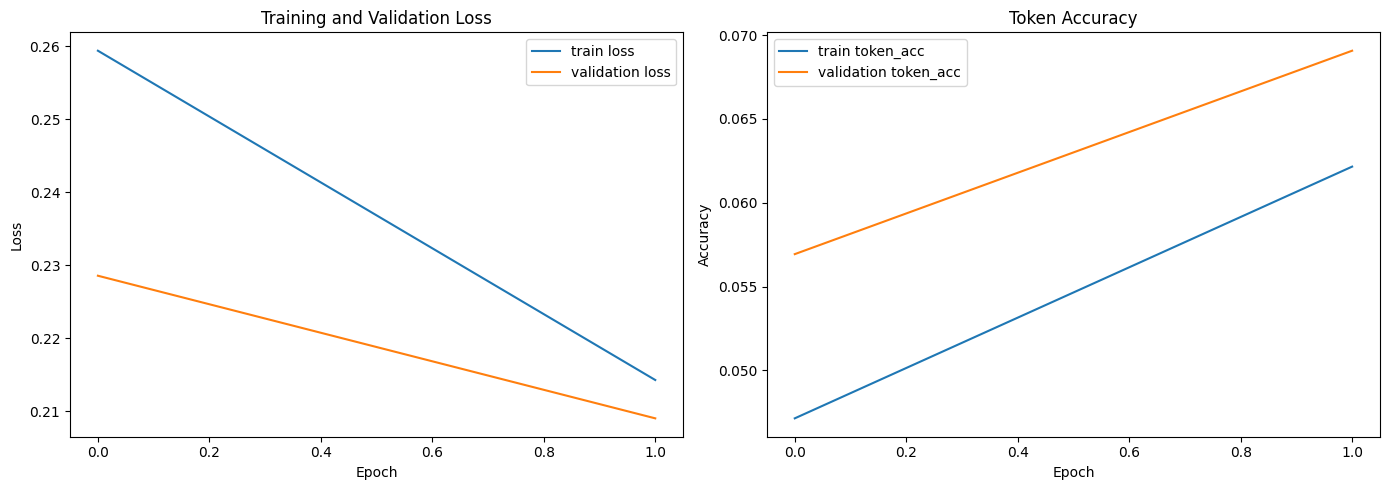

Best validation loss: 0.2091 at epoch 2
Total epochs trained: 2


In [17]:

history_df = pd.DataFrame(history.history)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='train loss')
axes[0].plot(history.history['val_loss'], label='validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()

if 'token_acc' in history.history:
    axes[1].plot(history.history['token_acc'], label='train token_acc')
    axes[1].plot(history.history['val_token_acc'], label='validation token_acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Token Accuracy')
    axes[1].legend()

plt.tight_layout()
plt.show()

best_epoch = int(np.argmin(history.history['val_loss'])) + 1
best_loss = float(np.min(history.history['val_loss']))
print(f'Best validation loss: {best_loss:.4f} at epoch {best_epoch}')
print(f'Total epochs trained: {len(history.history["loss"])}')



## Save the final training artifacts

This cell saves the final model, the tokenizer, the training config, and the training log.


In [18]:

model.save(str(FINAL_MODEL_PATH))

with open(TRAINING_CONFIG_PATH, 'w', encoding='utf-8') as handle:
    json.dump({
        'chatbot_name': CHATBOT_NAME,
        'config': CONFIG,
        'device': DEVICE,
        'seed': SEED,
    }, handle, indent=2)

print('Saved artifacts:')
print(f'  Best model:   {BEST_MODEL_PATH.resolve()}')
print(f'  Final model:  {FINAL_MODEL_PATH.resolve()}')
print(f'  Tokenizer:    {TOKENIZER_MODEL_PATH.resolve()}')
print(f'  Vocab:        {TOKENIZER_VOCAB_PATH.resolve()}')
print(f'  Config:       {TRAINING_CONFIG_PATH.resolve()}')
print(f'  Training log: {TRAINING_LOG_PATH.resolve()}')
print(f'  Checkpoints:  {CHECKPOINT_DIR.resolve()}')


Saved artifacts:
  Best model:   /tf/emma/best_emma.keras
  Final model:  /tf/emma/final_emma.keras
  Tokenizer:    /tf/emma/emma_tokenizer.model
  Vocab:        /tf/emma/emma_tokenizer.vocab
  Config:       /tf/emma/emma_training_config.json
  Training log: /tf/emma/emma_training_log.csv
  Checkpoints:  /tf/emma/checkpoints



## Reload the best checkpoint

This confirms that the saved best model can be loaded back into memory successfully.


In [19]:

reloaded_model = keras.models.load_model(str(BEST_MODEL_PATH), compile=False)
print(f'Reloaded best model from: {BEST_MODEL_PATH.resolve()}')
reloaded_model.summary()


Reloaded best model from: /tf/emma/best_emma.keras


Model: "emma"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed               │ (None, 384, 512)  │    708,608 │ input_ids[0][0]   │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 384)       │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384, 512)  │          0 │ embed[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 384)       │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_0 │ (None, 384, 512)  │  3,152,384 │ dropout[0][0],    │
│ (TransformerBlock)  │                   │            │ cast_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 384, 512)  │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ (None, 384, 512)  │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_3 │ (None, 384, 512)  │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_4 │ (None, 384, 512)  │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_5 │ (None, 384, 512)  │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_6 │ (None, 384, 512)  │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_7 │ (None, 384, 512)  │  3,152,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ cast_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_layer_norm    │ (None, 384, 512)  │      1,024 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lm_head (Dense)     │ (None, 384, 1000) │    513,000 │ final_layer_norm… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,441,704 (100.87 MB)

 Trainable params: 26,441,704 (100.87 MB)

 Non-trainable params: 0 (0.00 B)


## Text generation helpers

These helpers let the notebook run a few quick conversational tests after training.


In [20]:

def get_blocked_ngram_tokens(reply_tokens: list[int], ngram_size: int) -> set[int]:
    if ngram_size is None or ngram_size < 2:
        return set()

    prefix_len = ngram_size - 1
    if len(reply_tokens) < prefix_len:
        return set()

    prefix = tuple(reply_tokens[-prefix_len:])
    blocked = set()

    for start in range(len(reply_tokens) - ngram_size + 1):
        ngram = reply_tokens[start:start + ngram_size]
        if tuple(ngram[:-1]) == prefix:
            blocked.add(ngram[-1])

    return blocked


def apply_repetition_controls(logits: np.ndarray, reply_tokens: list[int]) -> np.ndarray:
    adjusted = logits.astype(np.float64).copy()

    banned_ids = {PAD_ID, USER_ID, ASSISTANT_ID}
    for banned_id in banned_ids:
        if 0 <= banned_id < len(adjusted):
            adjusted[banned_id] = -1e10

    if not reply_tokens:
        return adjusted

    repetition_penalty = CONFIG['preview_repetition_penalty']
    frequency_penalty = CONFIG['preview_frequency_penalty']
    recent_token_penalty = CONFIG['preview_recent_token_penalty']
    recent_token_window = CONFIG['preview_recent_token_window']
    no_repeat_ngram_size = CONFIG['preview_no_repeat_ngram_size']

    if repetition_penalty and repetition_penalty > 1.0:
        for token_id in set(reply_tokens):
            if 0 <= token_id < len(adjusted):
                if adjusted[token_id] >= 0:
                    adjusted[token_id] /= repetition_penalty
                else:
                    adjusted[token_id] *= repetition_penalty

    if frequency_penalty and frequency_penalty > 0:
        for token_id, count in Counter(reply_tokens).items():
            if 0 <= token_id < len(adjusted):
                adjusted[token_id] -= frequency_penalty * count

    if recent_token_penalty and recent_token_penalty > 0 and recent_token_window > 0:
        for token_id in reply_tokens[-recent_token_window:]:
            if 0 <= token_id < len(adjusted):
                adjusted[token_id] -= recent_token_penalty

    blocked_tokens = get_blocked_ngram_tokens(reply_tokens, no_repeat_ngram_size)
    for token_id in blocked_tokens:
        if 0 <= token_id < len(adjusted):
            adjusted[token_id] = -1e10

    return adjusted


def sample_next_token(logits, reply_tokens: list[int], temperature=0.8, top_k=40):
    logits = apply_repetition_controls(logits, reply_tokens)

    if temperature is None or temperature <= 0:
        return int(np.argmax(logits))

    logits = logits / temperature

    if top_k is not None and top_k > 0:
        top_k = min(int(top_k), len(logits))
        top_indices = np.argpartition(logits, -top_k)[-top_k:]
        top_logits = logits[top_indices]
        probs = np.exp(top_logits - np.max(top_logits))
        probs = probs / np.sum(probs)
        return int(np.random.choice(top_indices, p=probs))

    probs = np.exp(logits - np.max(logits))
    probs = probs / np.sum(probs)
    return int(np.random.choice(np.arange(len(logits)), p=probs))


def build_prompt_ids(conversation_turns: list[str]) -> list[int]:
    prompt_ids = [BOS_ID]
    for i, turn in enumerate(conversation_turns):
        role_token = SPECIAL_USER if i % 2 == 0 else SPECIAL_ASSISTANT
        prompt_ids.extend(encode_turn(role_token, normalize_text(turn)))
    prompt_ids.append(ASSISTANT_ID)
    return prompt_ids


def generate_reply(model, conversation_turns: list[str], max_new_tokens=80, temperature=0.8, top_k=40):
    prompt_ids = build_prompt_ids(conversation_turns)
    generated = prompt_ids[:]
    new_tokens = []

    for _ in range(max_new_tokens):
        x = generated[-CONFIG['max_seq_len']:]
        if len(x) < CONFIG['max_seq_len']:
            x = x + [PAD_ID] * (CONFIG['max_seq_len'] - len(x))

        x_tensor = np.array([x], dtype=np.int32)
        logits = model(x_tensor, training=False)[0].numpy()
        last_real_idx = max(i for i, token_id in enumerate(x) if token_id != PAD_ID)
        next_logits = logits[last_real_idx]
        next_id = sample_next_token(
            next_logits,
            reply_tokens=new_tokens,
            temperature=temperature,
            top_k=top_k,
        )

        if next_id in (EOS_ID, SEP_ID):
            break

        generated.append(next_id)
        new_tokens.append(next_id)

    return sp.decode(new_tokens).strip()



## Quick chat preview

This is a simple sanity check. It lets you see how the model responds to a small fixed prompt set after training.


In [21]:

chat_model = reloaded_model

test_prompts = [
    'Explain the difference between supervised learning and unsupervised learning in simple terms.',
    'Give one concrete real-world example of each.',
    'Turn that into five short study notes I could review before an exam.',
    'Now add three beginner interview questions on the same topic.',
    'Write concise model answers for those questions.',
    'Give me one common misunderstanding students have about this topic and correct it clearly.',
    'Summarize everything into a short cheat sheet with headings.',
    'Finish with a three-step revision plan for tonight.',
]

conversation_turns = []
for prompt in test_prompts:
    print('─' * 60)
    print(f'You:  {prompt}')
    reply = generate_reply(
        chat_model,
        conversation_turns + [prompt],
        max_new_tokens=CONFIG['preview_max_new_tokens'],
        temperature=CONFIG['preview_temperature'],
        top_k=CONFIG['preview_top_k'],
    )
    print(f'Bot:  {reply}')
    conversation_turns.append(prompt)
    conversation_turns.append(reply)

print('─' * 60)


────────────────────────────────────────────────────────────
You:  Explain the difference between supervised learning and unsupervised learning in simple terms.
Bot:  What kind of job did you take?
────────────────────────────────────────────────────────────
You:  Give one concrete real-world example of each.
Bot:  Agreed, but it's a good way to be a great feeling.
────────────────────────────────────────────────────────────
You:  Turn that into five short study notes I could review before an exam.
Bot:  I would be so. Maybe you should try some new friends!
────────────────────────────────────────────────────────────
You:  Now add three beginner interview questions on the same topic.
Bot:  Agreed! I'm happy for that, but I love them from home.
────────────────────────────────────────────────────────────
You:  Write concise model answers for those questions.
Bot:  That's a good idea! At the delivery is fun. It will be very awesome, but I'm sure it will seem like you!
───────────────────